<a href="https://colab.research.google.com/github/Syda2376/Data-Analysis/blob/car-sales-analysis/car_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1️⃣ Introduction
This project analyzes a real-world car sales dataset to identify top-performing dealers, companies, and models. The analysis also explores customer purchasing behavior and time-based sales trends to generate actionable business insights.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("car_sales.csv")
df.head()


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Double Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,Double Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,Double Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


# 2️⃣ Dataset Overview

The dataset contains columns such as Date, Dealer_name, Company, Model, Price, Gender, Annual_Income, Transmission, Engine, Body Style, Dealer Region.

The original dataset contains 23,906 records and 16 columns, including sales, customer, dealer, and vehicle attributes.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [79]:
df.isnull().sum()

,0
Car_id,0
Date,0
Customer Name,1
Gender,0
Annual Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


Info checked, missing values are: 0

# 3️⃣ Data Cleaning & Preprocessing

Dropped irrelevant columns (Car_id, dealer_no, color), corrected columns and removed duplicates.

After data cleaning, the dataset contains 23,906 records and 13 relevant columns.

In [111]:
df.columns = df.columns.str.strip()
df = df.drop(columns=['Car_id', 'Dealer_No', 'Color', 'Phone', 'Customer Name'], errors='ignore')
df = df.rename(columns={'Price ($)': 'Price'})
df = df.drop_duplicates()

Dropped irrelevant identifier and personal columns, standardized column names, removed duplicates, and converted the Date column to datetime format.

In [103]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           23906 non-null  datetime64[ns]
 1   Gender         23906 non-null  object        
 2   Annual Income  23906 non-null  int64         
 3   Dealer_Name    23906 non-null  object        
 4   Company        23906 non-null  object        
 5   Model          23906 non-null  object        
 6   Engine         23906 non-null  object        
 7   Transmission   23906 non-null  object        
 8   Price          23906 non-null  int64         
 9   Body Style     23906 non-null  object        
 10  Dealer_Region  23906 non-null  object        
 11  Month          23906 non-null  period[M]     
dtypes: datetime64[ns](1), int64(2), object(8), period[M](1)
memory usage: 2.2+ MB


(23906, 12)

# 4️⃣ Feature Engineering

New time-based features were created from the Date column to enable trend and seasonal analysis. Specifically, month and year values were extracted to analyze sales patterns over time.

In [110]:
# Extract month and year from Date column for time-based analysis
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year

# Preview new features
df[['Date', 'Month', 'Year']].head()


,Date,Month,Year
0,2022-01-02,2022-01,2022
1,2022-01-02,2022-01,2022
2,2022-01-02,2022-01,2022
3,2022-01-02,2022-01,2022
4,2022-01-02,2022-01,2022


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           23906 non-null  datetime64[ns]
 1   Gender         23906 non-null  object        
 2   Annual Income  23906 non-null  int64         
 3   Dealer_Name    23906 non-null  object        
 4   Company        23906 non-null  object        
 5   Model          23906 non-null  object        
 6   Engine         23906 non-null  object        
 7   Transmission   23906 non-null  object        
 8   Price          23906 non-null  int64         
 9   Body Style     23906 non-null  object        
 10  Dealer_Region  23906 non-null  object        
 11  Month          23906 non-null  period[M]     
 12  Year           23906 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(2), object(8), period[M](1)
memory usage: 2.3+ MB


# 5️⃣ Exploratory Data Analysis (EDA)

Analyzing dealer-wise, company-wise, model-wise, and gender-based sales patterns.

In [82]:
#Group data by Dealer_name
# We calculate total and average sales per dealer to identify top-performing dealers
dealer_sales = df.groupby('Dealer_Name')['Price'].agg(['sum','mean']).sort_values('sum', ascending=False)
print(dealer_sales)

                                                      sum          mean
Dealer_Name                                                            
Rabun Used Car Sales                             37456655  28527.536177
Progressive Shippers Cooperative Association No  36751460  27884.264036
U-Haul CO                                        35876089  28769.919006
Race Car Help                                    35288706  28163.372706
Saab-Belle Dodge                                 35265865  28190.139888
Scrivener Performance Engineering                35258525  28297.371589
Star Enterprises Inc                             35113206  28113.055244
Tri-State Mack Inc                               35091357  28095.562050
Suburban Ford                                    34943473  28112.206758
Ryder Truck Rental and Leasing                   34837906  27914.988782
Iceberg Rentals                                  17883895  28522.958533
Classic Chevy                                    17819055  28602

In [83]:
# Group data by company
# We calculate total sales per car company to find the most profitable brands
company_sales = df.groupby('Company')['Price'].sum().sort_values(ascending=False)
print(company_sales)


Company
Chevrolet     47655265
Ford          47231583
Dodge         44124996
Oldsmobile    35434512
Mercedes-B    34624123
Volkswagen    34082881
Mitsubishi    34062466
Toyota        32759564
Chrysler      29141873
Lexus         27287703
Cadillac      26713805
Mercury       24939733
Nissan        23964095
Pontiac       23369207
Volvo         21925200
Honda         19882735
BMW           19821592
Saturn        18220269
Plymouth      18142873
Acura         17058649
Lincoln       15452262
Buick         14765485
Subaru        11312193
Audi          10694638
Porsche        8185637
Saab           7668431
Jeep           7643814
Infiniti       5717040
Hyundai        5117966
Jaguar         4524875
Name: Price, dtype: int64


In [84]:
# Group data by model
# Identify the top 5 car models by total sales to see which models are most popular
top_models = df.groupby('Model')['Price'].sum().sort_values(ascending=False).head(5)
print(top_models)

Model
LS400            14263424
Jetta            12287736
Silhouette       12271849
Montero Sport    11472231
Ram Pickup       10655391
Name: Price, dtype: int64


In [85]:
# Group data by Gender
# Calculate average price paid by each gender to understand customer purchasing patterns
gender_sales = df.groupby('Gender')['Price'].mean()
print(gender_sales)

Gender
Female    28277.265270
Male      28039.429407
Name: Price, dtype: float64


In [112]:
# Income-based purchasing behavior
income_price = df.groupby(pd.qcut(df['Annual Income'], 5))['Price'].mean()
income_price

/tmp/ipython-input-2889488641.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_price = df.groupby(pd.qcut(df['Annual Income'], 5))['Price'].mean()


,Price
Annual Income,
"(10079.999, 13500.0]",27878.018582
"(13500.0, 620000.0]",28132.007163
"(620000.0, 865000.0]",27834.126519
"(865000.0, 1300000.0]",28468.153830
"(1300000.0, 11200000.0]",28162.582432


In [108]:
# Group by month to calculate total sales per month
monthly_sales = df.groupby('Month')['Price'].sum()
print(monthly_sales.sort_values(ascending = False))

Month
2023-12    54281601
2023-11    51590388
2023-09    51416962
2022-11    45389290
2022-12    44984458
2022-09    42218216
2023-05    32613157
2023-06    28901691
2023-07    28243030
2023-10    28043756
2023-08    25162276
2023-04    24115567
2022-10    23991509
2022-08    23631362
2022-04    22748867
2023-03    22203814
2022-05    20608086
2022-07    19935002
2022-06    19604211
2022-03    19502059
2023-01    12764298
2023-02    11848580
2022-01     8931920
2022-02     8795365
Freq: M, Name: Price, dtype: int64


# 6️⃣ Visualizations

We use bar charts for dealer and company sales, and a line chart to visualize monthly sales trends.

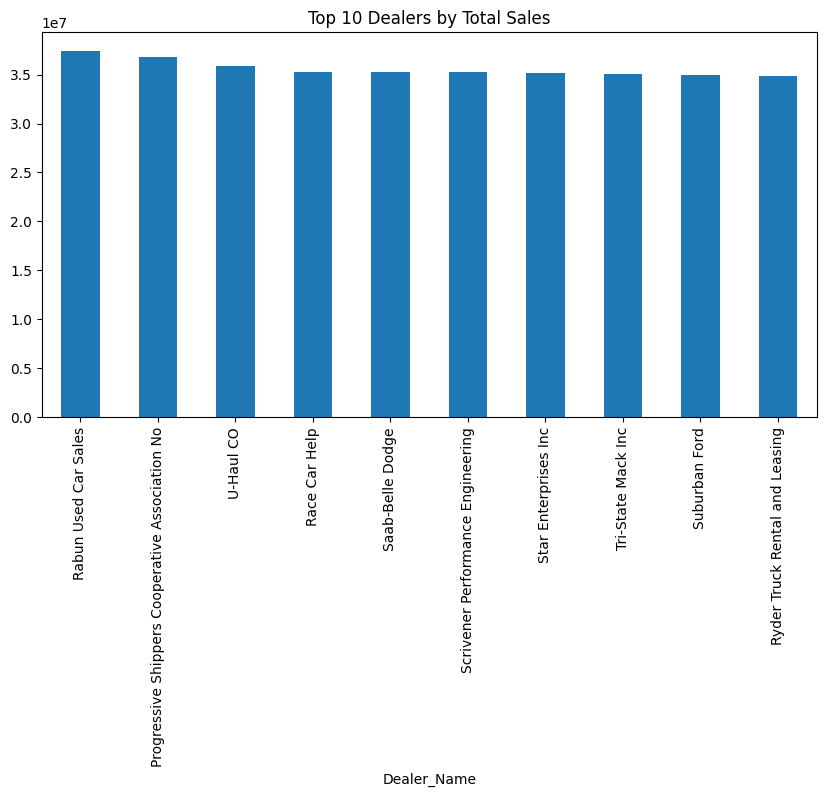

In [113]:
# Bar chart of total sales by dealer
# Helps us quickly identify the highest-performing dealerships
top_dealers = dealer_sales.head(10)

top_dealers['sum'].plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Dealers by Total Sales'
)
plt.show()


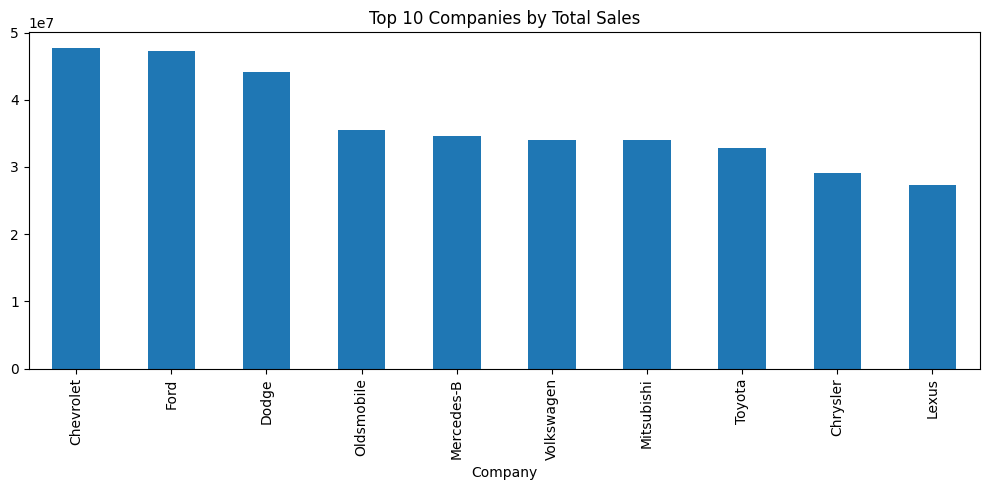

In [115]:
# Bar chart of total sales by company
# This visually shows which car brands generate the most revenue
top_companies = company_sales.head(10)

top_companies.plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Companies by Total Sales'
)
plt.tight_layout()
plt.show()


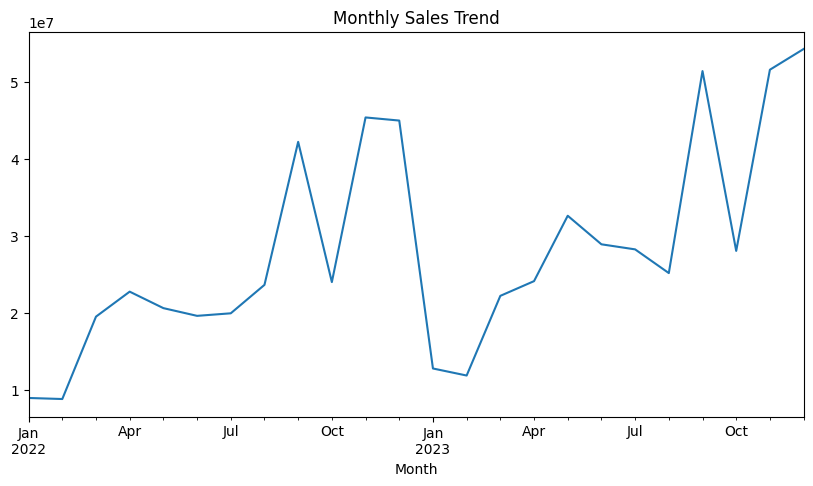

In [76]:
# Line chart of monthly sales
# This helps identify seasonal trends or sales spikes over time
monthly_sales.plot(kind='line', figsize=(10,5), title='Monthly Sales Trend')
plt.show()


# 7️⃣ Key Insights & Conclusion

* Rabun Used Car Sales emerged as the highest revenue-generating dealer.

* Chevrolet and Ford dominate total sales among all car brands.

* The LS400 model generated the highest total revenue across all vehicle models.

* Female customers show slightly higher average spending compared to male customers.

* Sales peaked in December 2023, indicating strong seasonal demand.

* Higher-income customers tend to purchase higher-priced vehicles.

# Conclusion
This analysis highlights key drivers of revenue across dealers, brands, and customer segments. The insights can support strategic decisions related to inventory planning, targeted marketing, and sales forecasting.